# 1.

In [1]:
text = """
Мне кажется, это важно проговорить

Месси делает невероятное. Мы никогда не видели человека, который бы ТАК (!) постиг игру.Превратив ее из сложной математической формулы в сердечко на асфальте.

Но прелесть Аргентины в том, что даже такой игрок–лишь часть чего-то большего.

Эта команда может обороняться вдесятером, пока Месси копит силы.Крепкая Австрия со своим прессингом не создала почти ничего!!!

Де Поль успевает раздавать передачи в стиле Хави,потом пробежать 30 метров, чтобы оказать давление на соперника, затем 30 метров назад, чтобы закрыть зону в обороне, которую Месси не закроет. Энцо Фернандес сохраняет мяч под давлением со спокойствием мажора, которого не избаловали. Мак Аллистер играет как два опорника.
Каждый в этой Аргентине техничен и умен. Минимум технического брака, минимум странных решений даже в микромоментах. Если выносят, так четко и наотмашь. Если фолят, так умело, что в голове судьи – синий экран: это желтая или не желтая? Если отдают под давлением, то в дальнюю ногу, что не отберешь, если не сфолишь.

Не футболисты – банда из Буэнос-Айреса. Хитрые, злые, умелые.
Эта команда может две минуты игнорировать лучшего игрока в истории, чтобы взорваться за 10 секунд и провести вертикальную атаку, будто прессинг Австрии какая-то шутка.

А в 2022-м это была еще более вертикальная команда, потому что меньше дорожила мячом как инструментом обороны. Потому что Месси тогда был сильнее и опаснее. Риск был оправдан. Сейчас она осторожнее и бережливее. К себе и тому, кто делает невероятное.

Эта команда интуитивно понимает, как прикрывать главную уязвимость (Месси в обороне). В каждом единоборстве. Когда сфолить, куда добежать, как расставиться, кому подстраховать. Такому можно научить только через культуру, через тысячи дворов меж узких улочек. Такое можно только вспомнить.

Эта команда Лионеля Скалони.

"""

In [2]:
from razdel import sentenize
from nltk.tokenize import word_tokenize
from pymorphy3 import MorphAnalyzer
from collections import Counter
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
sentences = [s.text for s in sentenize(text)]

In [4]:
sentences[14]

'Эта команда может две минуты игнорировать лучшего игрока в истории, чтобы взорваться за 10 секунд и провести вертикальную атаку, будто прессинг Австрии какая-то шутка.'

In [6]:
tokens = word_tokenize(sentences[14], language="Russian")

In [9]:
print(tokens)

['Эта', 'команда', 'может', 'две', 'минуты', 'игнорировать', 'лучшего', 'игрока', 'в', 'истории', ',', 'чтобы', 'взорваться', 'за', '10', 'секунд', 'и', 'провести', 'вертикальную', 'атаку', ',', 'будто', 'прессинг', 'Австрии', 'какая-то', 'шутка', '.']


In [7]:
morph = MorphAnalyzer()

In [10]:
pos_tags = []
for token in tokens:
    parses = morph.parse(token)
    if parses:
        last_parse = parses[-1]
        pos_tags.append(last_parse.tag.POS)

In [13]:
print(pos_tags)

['ADJF', 'NOUN', 'CONJ', 'NUMR', 'NOUN', 'INFN', 'ADJF', 'NOUN', 'NOUN', 'NOUN', None, 'PRCL', 'INFN', 'PREP', None, 'NOUN', 'NOUN', 'INFN', 'ADJF', 'NOUN', None, 'INTJ', 'NOUN', 'NOUN', 'ADJF', 'NOUN', None]


In [15]:
count_noun = Counter(pos_tags)["NOUN"]
print(f"Количество NOUN: {count_noun}")

Количество NOUN: 11


# 2.

## a.

In [22]:
# from sklearn.metrics import f1_score, fbeta_score
from sklearn.metrics import precision_score, recall_score
import numpy as np
from collections import Counter

In [17]:
binary_true = [1,1,1,1,0,1,0,1,0,1,0,0,0,0,1,1]
multiclass_true = [1,2,0,0,3,4,0,1,2,2,4,0,0,1,3]

In [18]:
import numpy as np
def predict_random(n_classes: int, length: int):
    preds = []
    for i in range(length):
        preds.append(np.random.randint(0,n_classes))
    return preds

In [19]:
# пример использования
# один вызов - одно предсказание заданной длины
# вам нужно вызвать каждую 5000 раз
# predict_random(2, 16)
# predict_random(5, 15)

In [20]:
np.random.seed(42)

In [24]:
precisions = []
for _ in range(5000):
    pred = predict_random(2, 16)
    p = precision_score(binary_true, pred, zero_division=0)
    precisions.append(p)

mean_precision = np.mean(precisions)

In [26]:
mean_precision

np.float64(0.5636844216894217)

## б.

In [27]:
recalls = []
for _ in range(5000):
    pred = predict_random(5, 15)
    r = recall_score(multiclass_true, pred, average='macro', zero_division=0)
    recalls.append(r)

mean_recall = np.mean(recalls)

In [28]:
mean_recall

np.float64(0.200116)

# 3.

In [29]:
descriptions = [
    "A fluffy white dog lying on grass with a puppy.",
    "Two white Samoyed dogs resting outdoors.",
    "A large white dog and a small puppy in a park.",
    "A smiling fluffy dog sitting beside a puppy.",
    "A white adult dog lying on the grass.",
    "A white puppy resting next to a larger dog.",
    "Two fluffy white dogs in a shaded grassy area.",
    "A Samoyed dog with a puppy under trees.",
    "A large dog and puppy posing on green grass.",
    "A happy white dog with its mouth open.",
    "A small white puppy leaning near an adult dog.",
    "Two dogs relaxing in a sunny park.",
    "A fluffy adult dog and puppy on a lawn.",
    "A white dog wearing a tag lies beside a puppy.",
    "A puppy and adult dog resting together outside.",
    "Two white dogs surrounded by grass and trees.",
    "A large fluffy dog sits protectively near a puppy.",
    "A Samoyed puppy and adult Samoyed outdoors.",
    "A cute white puppy lying beside a big dog.",
    "Two companion dogs lying in the grass.",
    "A white fluffy dog with crossed front paws.",
    "A puppy partially hidden next to a larger dog.",
    "A bright outdoor scene with two white dogs.",
    "A large smiling dog and a calm puppy.",
    "Two fluffy dogs resting in a green garden."
]

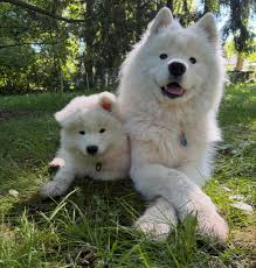

In [30]:
from PIL import Image
from torchvision import transforms
import requests
# Вспомогательные ресайзы, чтобы картинки в ноутбуке не занимали весь экран
to_256 = transforms.Resize(256)

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTi8nMXP146ynt5kIKD7jcO8mf9_wwTxaUadA&s"
image = Image.open(requests.get(url, stream=True).raw)
to_256(image)

# 4.